In [ ]:
from micrograd.engine import Value 

import random

# so similarly pytorch has nn module for this. 
class Neuron: 
    def __init__(self, nin: int, nonlin: bool = True): 
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))
        self.nonlin = nonlin
    
    def __call__(self, x: list):
        act = self.b
        # for w1, x1 in zip(self.w, x): 
        #     act += w1 * x1 
        # act = act.relu()
        act = sum((w1*x1 for w1, x1 in zip(self.w, x)), self.b)
        return act.relu() if self.nonlin else act

    def parameters(self): 
        return self.w + [self.b]

    def __repr__(self): 
        return f"Neuron(nin={len(self.w)}), w1={self.w[0].data:.2f}, b={self.b.data:.2f}"
        
class Layer: 
    def __init__(self, nin: int, nout: int, nonlin: bool = True): 
        self.neurons = [Neuron(nin, nonlin) for _ in range(nout)]
    
    def __call__(self, x: list): 
        # out = []
        # for neuron in self.neurons: 
        #     out.append(neuron(x))
        # print(out)
        out = [neuron(x) for neuron in self.neurons]
        return out 

    def parameters(self): 
        # p = []
        # for neuron in self.neurons: 
        #     for param in neuron.parameters(): 
        #         p.extend(param)
        # return p
        return [p for neuron in self.neurons for p in neuron.parameters()]

    def __repr__(self): 
        return f"Layer(neurons={len(self.neurons)})"

class MLP: 
    def __init__(self, nin: int, nouts: list): 
        # self.layers = []
        sz = [nin] + nouts
        # for i in range(len(nouts)): 
        #     self.layers.append(Layer(sz[i], sz[i+1]))
        self.layers = [Layer(sz[i], sz[i+1], nonlin= i != len(nouts) - 1) for i in range(len(nouts))]

    
    def __call__(self, x: list): 
        for layer in self.layers: 
            x = layer(x)
            # asdfasdfasdf
        return x

    def parameters(self): 
        return [p for layer in self.layers for p in layer.parameters()]

    def __repr__(self): 
        return f"MLP(layers={len(self.layers)})"

In [90]:
a = Neuron(3)

In [92]:
print(len(a.parameters()))

4


In [43]:
print(a.w)

[Value(data=0.09517695066633869, grad=0), Value(data=0.6755856908954572, grad=0), Value(data=-0.6589526430143209, grad=0)]


In [44]:
print(a.b)

Value(data=-0.5871880346256779, grad=0)


In [45]:
x = [0.1, 0.05, 0.11]
# a(x) # equivalent to a.__call__(x)

In [97]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{data %.4f | grad %.4f  }" % (n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

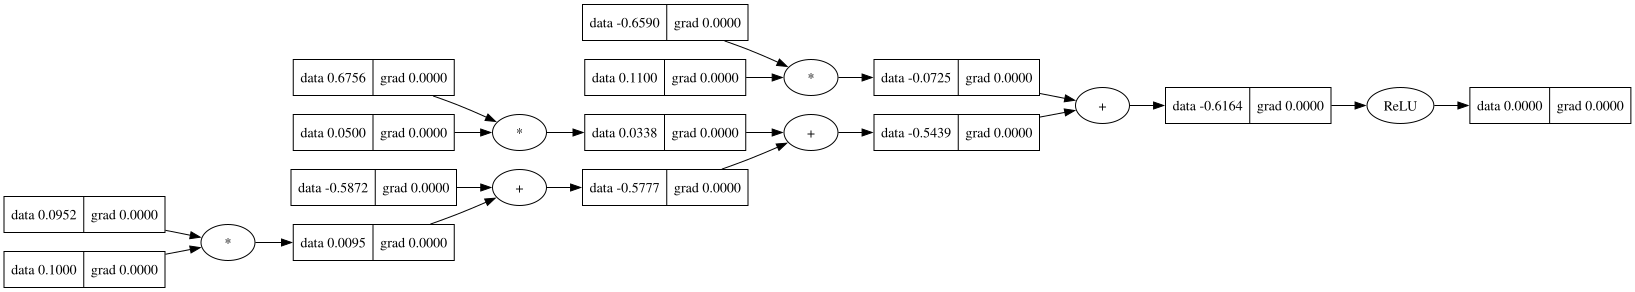

In [47]:
draw_dot(a(x))

In [93]:
b = Layer(3, 4)

In [94]:
print(len(b.parameters()))

16


In [70]:
print(b.neurons)

[Neuron(nin=3), w1=-0.05, b=-0.27, Neuron(nin=3), w1=0.05, b=0.69, Neuron(nin=3), w1=-0.41, b=0.95, Neuron(nin=3), w1=-0.67, b=-0.61]


In [71]:
print(len(b.neurons))

4


In [72]:
x = [0.1, 0.05, 0.11]
b(x) # b.__call__(x)

[Value(data=0, grad=0),
 Value(data=0.5737617363138616, grad=0),
 Value(data=0.9462709183490216, grad=0),
 Value(data=0, grad=0)]

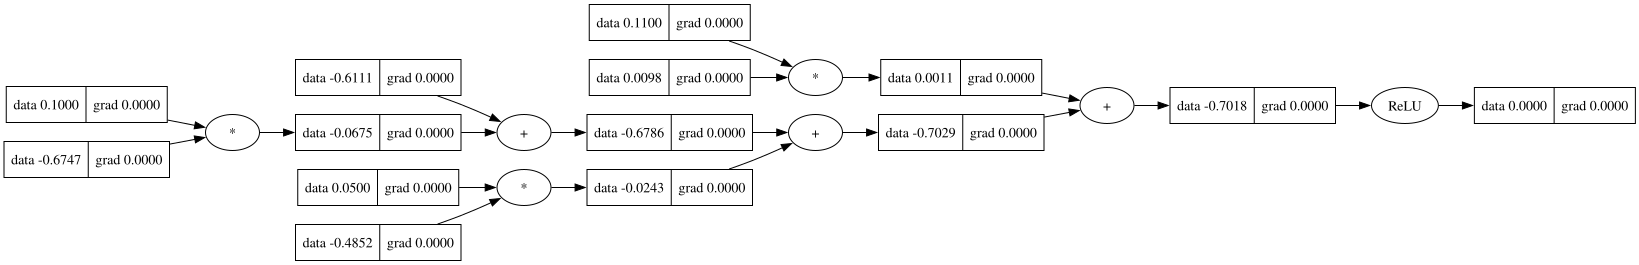

In [ ]:
draw_dot(b(x)[0])
# draw_dot(b(x)[1])
# draw_dot(b(x)[2])
# draw_dot(b(x)[3])

In [102]:
m = MLP(3, [4, 5, 1])

In [96]:
print(len(m.parameters()))

47


In [81]:
print(m.layers)

[Layer(neurons=4), Layer(neurons=5), Layer(neurons=1)]


In [83]:
print(m.layers[0].neurons)

[Neuron(nin=3), w1=0.89, b=-0.45, Neuron(nin=3), w1=0.90, b=-0.70, Neuron(nin=3), w1=0.22, b=-0.34, Neuron(nin=3), w1=0.72, b=0.63]


In [ ]:
x = [0.1, 0.05, 0.11]
m(x) # m.__call__(x)

[Value(data=0, grad=0)]

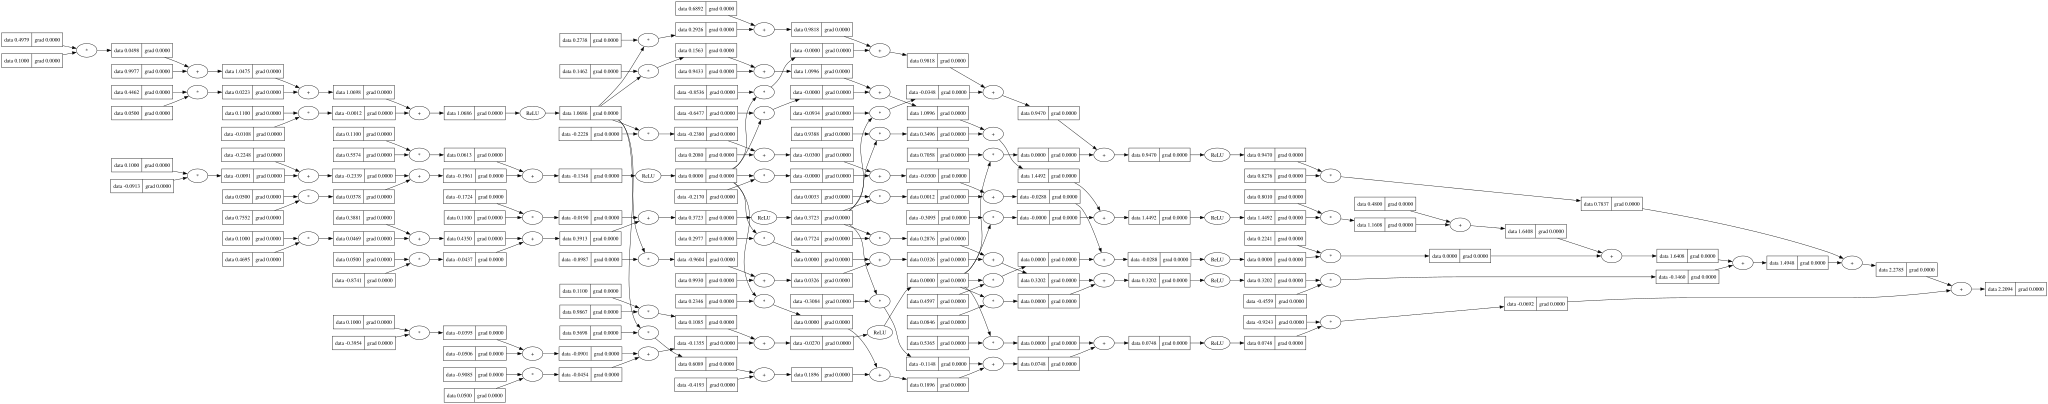

In [103]:
draw_dot(m(x)[0])